# Description

In this notebook, we prepare the illustration plots of parameter convergence for different operations. The operations include division, and sine.

# 1. Division

device: cpu | N: 100 | y_true min/max: -33.00009536743164 33.00009536743164

Real model:
  epochs: 289
  best MSE: 53.72098159790039
  final a: 1.5153974294662476

Complex model:
  epochs: 3298
  best MSE: 2.5247112489523715e-07
  final a: 0.000000 + -0.000706j


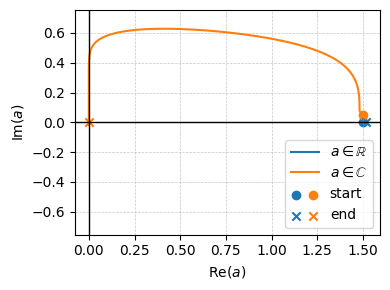

In [31]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.legend_handler import HandlerTuple

# ---- setup + data (CPU only) ----
torch.manual_seed(0)

x = torch.linspace(-3.0, 3.0, 100)
x = x[x != 0.0]
y_true = 1.0 / x

clip_y = 100.0
mask = y_true.abs() <= clip_y
x, y_true = x[mask], y_true[mask]

print("device: cpu | N:", x.numel(), "| y_true min/max:", y_true.min().item(), y_true.max().item())

# ---- models ----
class RealShiftDivision(nn.Module):
    def __init__(self, a0=1.0):
        super().__init__()
        self.a = nn.Parameter(torch.tensor(a0))

    def forward(self, x):
        return 1.0 / (x + self.a)

class ComplexShiftDivision(nn.Module):
    def __init__(self, a0=1.0, a_imag0=0.1):
        super().__init__()
        self.a = nn.Parameter(torch.complex(torch.tensor(a0), torch.tensor(a_imag0)))

    def forward(self, x, eps=1e-6):
        z = x.to(torch.complex64) + self.a
        z = torch.where(z.abs() < eps, eps + 0.0j * z, z)
        return (1.0 / z).real

# ---- training (Adam + stop on plateau) + trajectory logging ----
def fit_with_traj(model, x, y_true, lr=1e-3, max_epochs=20000, plateau_tol=1e-6, patience=200):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    best = float("inf")
    no_improve = 0

    traj_re, traj_im = [], []

    for epoch in range(1, max_epochs + 1):
        with torch.no_grad():
            a = model.a.detach()
            if torch.is_complex(a):
                traj_re.append(float(a.real))
                traj_im.append(float(a.imag))
            else:
                traj_re.append(float(a))
                traj_im.append(0.0)

        opt.zero_grad(set_to_none=True)
        loss = mse(model(x), y_true)
        loss.backward()
        opt.step()

        loss_val = loss.item()
        if loss_val < best - plateau_tol:
            best = loss_val
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    with torch.no_grad():
        a = model.a.detach()
        if torch.is_complex(a):
            traj_re.append(float(a.real))
            traj_im.append(float(a.imag))
        else:
            traj_re.append(float(a))
            traj_im.append(0.0)

    return epoch, best, traj_re, traj_im

# ---- run ----
a0 = 1.5
a_imag0 = 0.05

m_real = RealShiftDivision(a0)
m_cplx = ComplexShiftDivision(a0, a_imag0)

e_r, best_r, re_r, im_r = fit_with_traj(m_real, x, y_true)
e_c, best_c, re_c, im_c = fit_with_traj(m_cplx, x, y_true)

print("\nReal model:")
print("  epochs:", e_r)
print("  best MSE:", best_r)
print("  final a:", float(m_real.a.detach()))

print("\nComplex model:")
a = m_cplx.a.detach().numpy()
print("  epochs:", e_c)
print("  best MSE:", best_c)
print(f"  final a: {a.real:.6f} + {a.imag:.6f}j")

# ---- plot trajectories in (Re(a), Im(a)) ----
im_abs_max = max(1e-3, max(abs(v) for v in im_c))
im_lim = 1.2 * im_abs_max

plt.figure(figsize=(4.0, 3.0))

line_real, = plt.plot(re_r, im_r, label=r"$a\in\mathbb{R}$")
line_cplx, = plt.plot(re_c, im_c, label=r"$a\in\mathbb{C}$")

start_real = plt.scatter(re_r[0], im_r[0], marker="o", color=line_real.get_color())
start_cplx = plt.scatter(re_c[0], im_c[0], marker="o", color=line_cplx.get_color())
end_real   = plt.scatter(re_r[-1], im_r[-1], marker="x", color=line_real.get_color())
end_cplx   = plt.scatter(re_c[-1], im_c[-1], marker="x", color=line_cplx.get_color())

plt.axhline(0.0, linewidth=1.0, color="black")
plt.axvline(0.0, linewidth=1.0, color="black")

plt.xlabel(r"$\mathrm{Re}(a)$")
plt.ylabel(r"$\mathrm{Im}(a)$")
plt.ylim(-im_lim, im_lim)
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)

# ---- legend: 4 entries total ----
start_tuple = (start_real, start_cplx)
end_tuple = (end_real, end_cplx)

handles = [line_real, line_cplx, start_tuple, end_tuple]
labels = [r"$a\in\mathbb{R}$", r"$a\in\mathbb{C}$", "start", "end"]

plt.legend(
    handles, labels,
    handler_map={tuple: HandlerTuple(ndivide=None)},
    loc="best"
)

plt.tight_layout()

# ---- save figure ----
os.makedirs("figures", exist_ok=True)
plt.savefig("figures/division_convergence.pdf", bbox_inches='tight')

plt.show()
